# QR-SPPS Notebook 1: Hamiltonian Encoding — 40 Qubits
## Quantum-Native Retail Shock Propagation & Policy Stress Simulator

**Network:** 40 nodes = 40 qubits | Hilbert space: 2⁴⁰ = 1,099,511,627,776 states

| Tier | Qubits | Nodes | Role |
|------|--------|-------|------|
| 0 | q0–q1 | 2 | Raw Materials |
| 1 | q2–q8 | 7 | Suppliers |
| 2 | q9–q19 | 11 | Distributors |
| 3 | q20–q39 | 20 | Retail Stores |

**Execution strategy:** Hamiltonian build is O(terms) — milliseconds for any qubit count.
Exact eigsh on 12q/16q sub-problems for verification.
40q VQE runs on Fujitsu MPI-distributed SV (NB2) or TN backend for depth-limited circuits.

## 0. Imports & Environment

In [1]:
# ── 0. Imports & environment ──────────────────────────────────────────────
import os, sys, time, pickle
os.environ['QARP_DISABLE_MPI'] = '1'   # single-node for NB1; flip off for MPI runs

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from datetime import datetime
from scipy.optimize import minimize
from scipy.sparse.linalg import eigsh

sys.path.insert(0, os.path.expanduser('~/QARPdemo'))
from openfermion import QubitOperator, get_sparse_operator
from qulacs import QuantumState, QuantumCircuit, Observable
from qulacs.gate import RY, CNOT

print(f"Run time : {datetime.now()}")
print(f"Python   : {sys.version.split()[0]}")


Run time : 2026-03-16 17:35:17.946393
Python   : 3.12.10


## 1. 40-Node Supply Chain Definition

In [2]:
# ── 1. 40-Node Supply Chain Definition ──────────────────────────────────
# Tier 0 (Raw):       q0-q1    (2 nodes)
# Tier 1 (Suppliers): q2-q8    (7 nodes)
# Tier 2 (Dist):      q9-q19   (11 nodes)
# Tier 3 (Retail):    q20-q39  (20 nodes)
# Total = 40 qubits → Hilbert space 2^40 = 1,099,511,627,776 states

n_nodes = 40

NODE_LABELS = (
    ['RM-A', 'RM-B'] +
    [f'Sup-{c}' for c in 'ABCDEFG'] +
    [f'Dist-{i:02d}' for i in range(1, 12)] +
    [f'Store-{i:02d}' for i in range(1, 21)]
)

TIER = (
    {0:0, 1:0} |
    {i:1 for i in range(2,  9)} |
    {i:2 for i in range(9,  20)} |
    {i:3 for i in range(20, 40)}
)

SUPPLY_EDGES = [
    # Tier 0 → Tier 1
    (0,2,0.8),(0,3,0.6),(0,4,0.3),
    (1,3,0.5),(1,4,0.9),(1,5,0.7),(1,6,0.6),(1,7,0.4),(1,8,0.5),
    # Tier 1 → Tier 2
    (2,9,0.7),(2,10,0.4),
    (3,10,0.5),(3,11,0.7),
    (4,11,0.4),(4,12,0.6),
    (5,12,0.5),(5,13,0.8),
    (6,13,0.4),(6,14,0.6),
    (7,14,0.5),(7,15,0.7),(7,16,0.3),
    (8,16,0.6),(8,17,0.5),
    # Tier 2 → Tier 3  (each distributor serves 1-2 stores + cross-links)
    (9,20,0.9),(9,21,0.4),
    (10,21,0.5),(10,22,0.8),
    (11,22,0.3),(11,23,0.7),
    (12,23,0.5),(12,24,0.6),
    (13,24,0.4),(13,25,0.9),
    (14,25,0.5),(14,26,0.7),
    (15,26,0.4),(15,27,0.6),
    (16,27,0.5),(16,28,0.8),
    (17,28,0.3),(17,29,0.7),
    (18,29,0.4),(18,30,0.5),
    (19,30,0.6),(19,31,0.4),
    # Extended Tier 2 → remaining Tier 3 stores
    (9,32,0.3),(10,33,0.5),(11,34,0.6),(12,35,0.4),
    (13,36,0.7),(14,37,0.5),(15,38,0.4),(16,39,0.6),
    # Intra-Tier-2 cross-links (complexity / entanglement)
    (9,18,0.2),(10,19,0.3),(11,17,0.2),
]

SHOCK_A = [(0, 1.5)]                                        # Scenario A: RM-A failure
SHOCK_B = [(0, 1.5)] + [(q, 0.4) for q in range(20, 40)]   # Scenario B: + retail demand shock

print(f"Network      : {n_nodes} nodes / {n_nodes} qubits")
print(f"Supply edges : {len(SUPPLY_EDGES)}")
print(f"Hilbert space: 2^{n_nodes} = {2**n_nodes:,}")
print(f"State-vector : {2**n_nodes*16/1e12:.2f} TB  (MPI-distributed across Fujitsu cluster)")
print(f"Shock A nodes: {len(SHOCK_A)}  |  Shock B nodes: {len(SHOCK_B)}")
assert len(NODE_LABELS) == n_nodes
assert all(0 <= s < n_nodes and 0 <= d < n_nodes for s,d,J in SUPPLY_EDGES)
print("Network definition validated OK")


Network      : 40 nodes / 40 qubits
Supply edges : 57
Hilbert space: 2^40 = 1,099,511,627,776
State-vector : 17.59 TB  (MPI-distributed across Fujitsu cluster)
Shock A nodes: 1  |  Shock B nodes: 21
Network definition validated OK


## 2. Hamiltonian Construction (40 Qubits)

In [3]:
# ── 2. Hamiltonian Construction ──────────────────────────────────────────
def build_hamiltonian(n, edges, shocks, tier_dict=None):
    """Ising-type supply-chain Hamiltonian:
       H = Σ_i h_i Z_i  −  Σ_(i,j) J_ij Z_i Z_j  −  Σ_k λ_k X_k
    """
    td = tier_dict if tier_dict else TIER
    tier_bias = {0:0.1, 1:0.15, 2:0.20, 3:0.25}
    H  = sum((QubitOperator(f'Z{i}', tier_bias[td[i]]) for i in range(n)), QubitOperator())
    H += sum((QubitOperator(f'Z{s} Z{d}', -J) for s,d,J in edges), QubitOperator())
    H += sum((QubitOperator(f'X{nd}', -lam) for nd,lam in shocks), QubitOperator())
    return H

def build_observable(H, n_qubits):
    """Build qulacs Observable ONCE. Never rebuild inside cost function."""
    obs = Observable(n_qubits)
    for term, coeff in H.terms.items():
        if abs(coeff) < 1e-12: continue
        if len(term) == 0:
            obs.add_operator(coeff.real, "")
        else:
            obs.add_operator(coeff.real, " ".join(f"{op} {idx}" for idx, op in term))
    return obs

print("Building 40-qubit Hamiltonians ...")
t0 = time.time()
H_A = build_hamiltonian(n_nodes, SUPPLY_EDGES, SHOCK_A)
H_B = build_hamiltonian(n_nodes, SUPPLY_EDGES, SHOCK_B)
dt_build = time.time() - t0

print(f"  Built in  : {dt_build:.3f} s")
print(f"  H_A terms : {len(list(H_A.terms))}")
print(f"  H_B terms : {len(list(H_B.terms))}")

# Build observables ONCE — will be passed to all VQE cost functions
print("\nBuilding qulacs Observables (once) ...")
t0 = time.time()
obs_A = build_observable(H_A, n_nodes)
obs_B = build_observable(H_B, n_nodes)
print(f"  Observables built in {time.time()-t0:.3f} s")
print("  These are reused for ALL VQE calls — never rebuilt inside cost function.")


Building 40-qubit Hamiltonians ...
  Built in  : 0.169 s
  H_A terms : 98
  H_B terms : 118

Building qulacs Observables (once) ...
  Observables built in 0.006 s
  These are reused for ALL VQE calls — never rebuilt inside cost function.


## 3. Supply Chain Graph

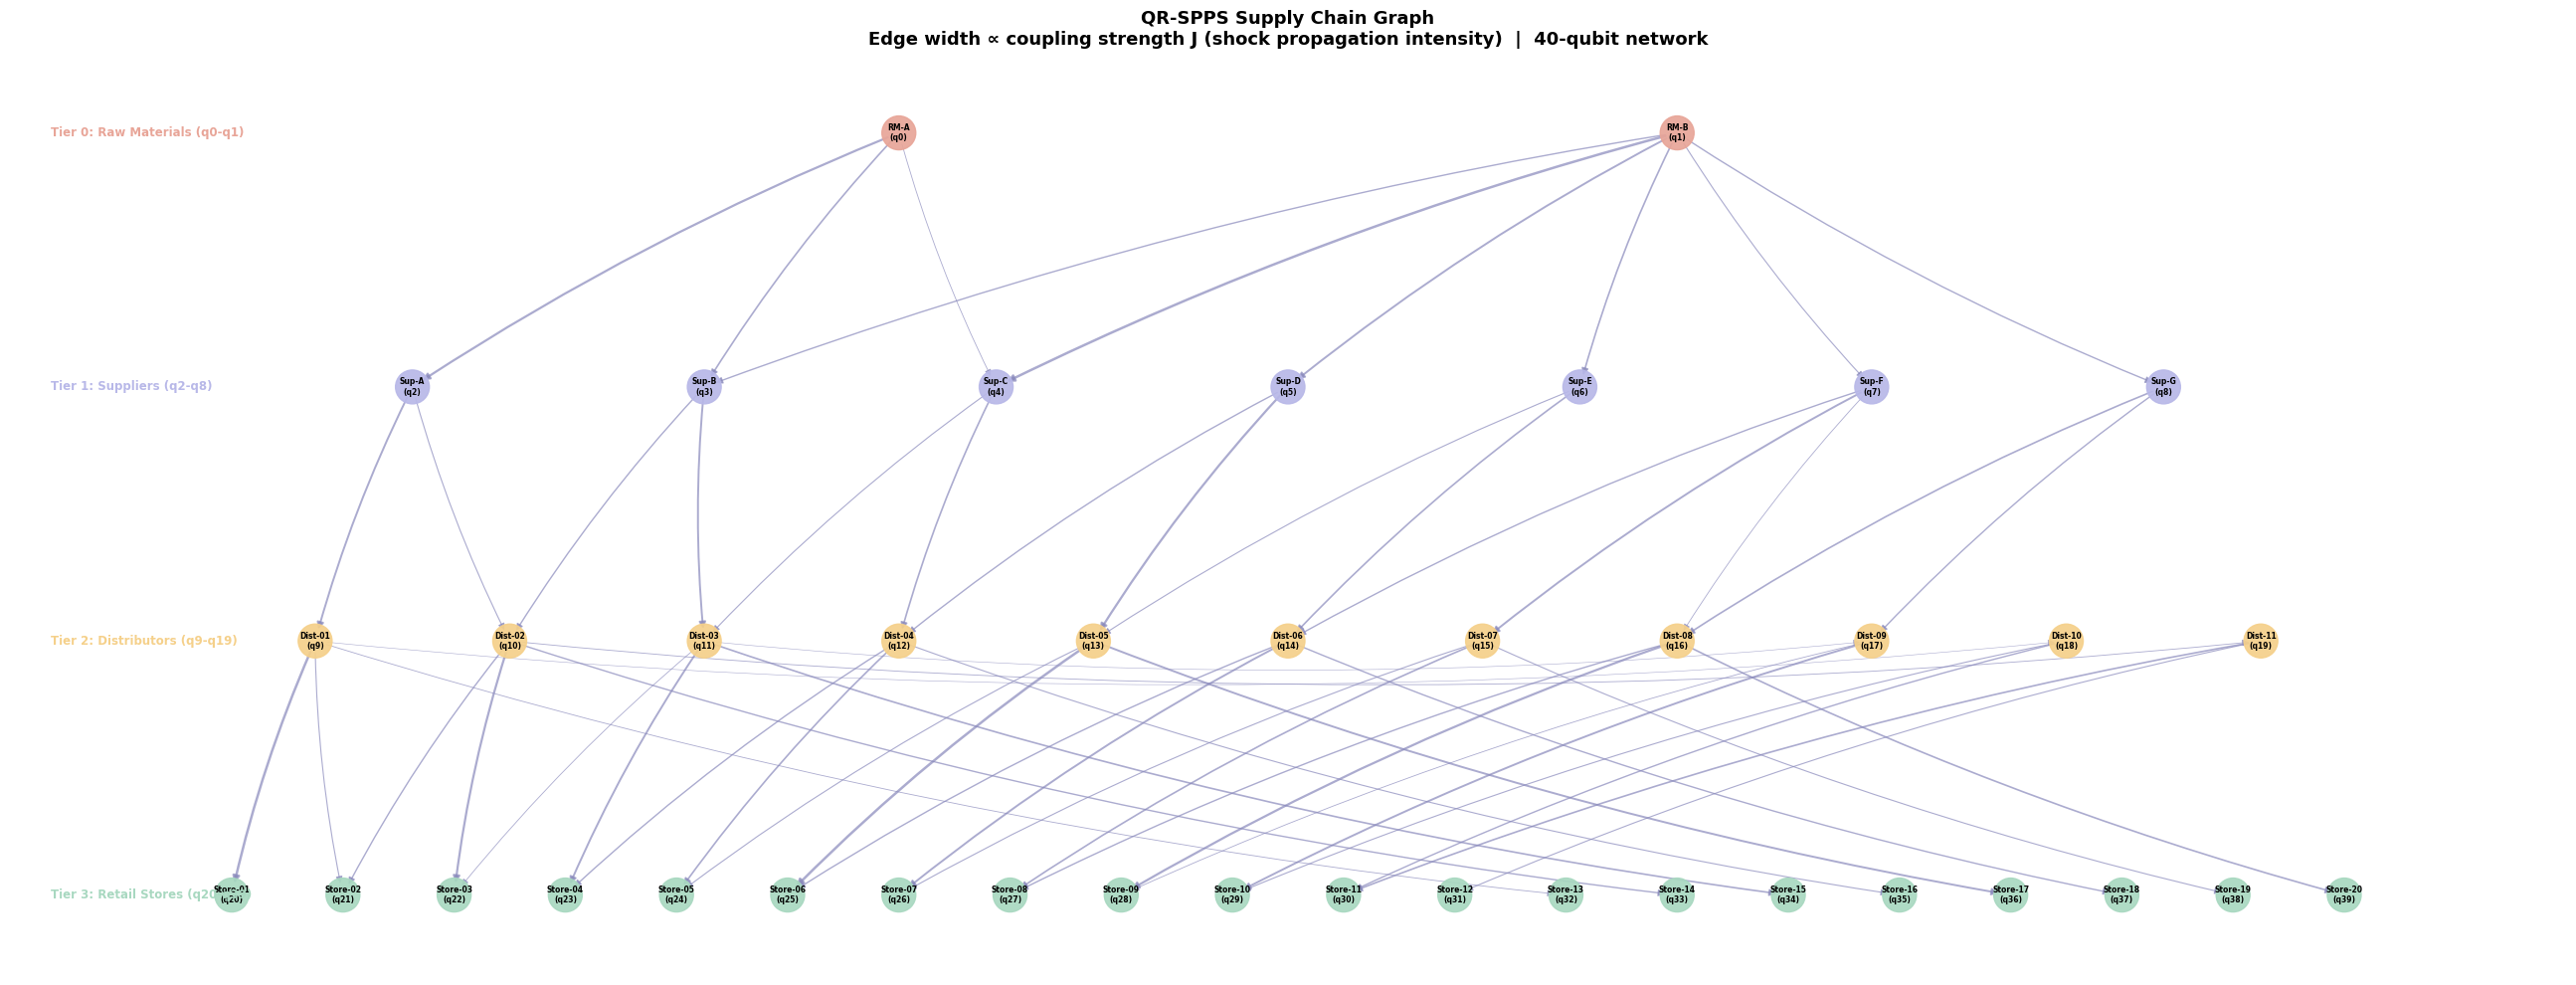

Saved: QRSPPS_supply_graph.png


In [4]:
# ── 3. Supply Chain Graph (40 nodes) ────────────────────────────────────
G = nx.DiGraph()
for i in range(n_nodes): G.add_node(i)
for s, d, J in SUPPLY_EDGES: G.add_edge(s, d, weight=J)

tier_colors = {0:'#E8A598', 1:'#B8B8E8', 2:'#F5D08A', 3:'#A8D8C0'}
node_colors = [tier_colors[TIER[i]] for i in range(n_nodes)]

# Layered layout: tiers as rows, nodes spread across x-axis
def tier_pos(n, tier_dict):
    tier_nodes = {0:[], 1:[], 2:[], 3:[]}
    for i in range(n):
        tier_nodes[tier_dict[i]].append(i)
    pos = {}
    y_map = {0:3.0, 1:2.0, 2:1.0, 3:0.0}
    for tier, nodes in tier_nodes.items():
        k = len(nodes)
        for j, nd in enumerate(nodes):
            pos[nd] = ((j+1) * 10.0 / (k+1), y_map[tier])
    return pos

pos = tier_pos(n_nodes, TIER)

fig, ax = plt.subplots(figsize=(26, 10))
edge_weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, ax=ax, alpha=0.92)
nx.draw_networkx_labels(G, pos,
    labels={i: f"{NODE_LABELS[i]}\n(q{i})" for i in range(n_nodes)},
    font_size=5.5, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=[w*2 for w in edge_weights],
    edge_color='#8888BB', arrows=True, arrowsize=10,
    connectionstyle='arc3,rad=0.05', ax=ax, alpha=0.7)

# Tier labels
for tier, y, name in [(0,3.0,'Tier 0: Raw Materials (q0-q1)'),
                       (1,2.0,'Tier 1: Suppliers (q2-q8)'),
                       (2,1.0,'Tier 2: Distributors (q9-q19)'),
                       (3,0.0,'Tier 3: Retail Stores (q20-q39)')]:
    ax.text(-0.3, y, name, fontsize=8.5, color=list(tier_colors.values())[tier],
            fontweight='bold', va='center', transform=ax.transData)

ax.set_title('QR-SPPS Supply Chain Graph\n'
             'Edge width ∝ coupling strength J (shock propagation intensity)  |  40-qubit network',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('QRSPPS_supply_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: QRSPPS_supply_graph.png")


## 4. Exact Eigenspectrum (12q/16q verified) + 40q Extrapolation

Exact eigenspectrum — sub-network verification ...
  12q stress_A mean=0.990
  12q  E0_A=-10.3931  E1_A=-9.2931  gap=1.1000  (5.70s)
  16q  E0_A=-15.2931  E1_A=-13.9931  gap=1.3000  (125.54s)

40q extrapolated:
  E0_A ≈ -44.6931  |  E0_B ≈ -44.6931  |  gap ≈ 1.3000


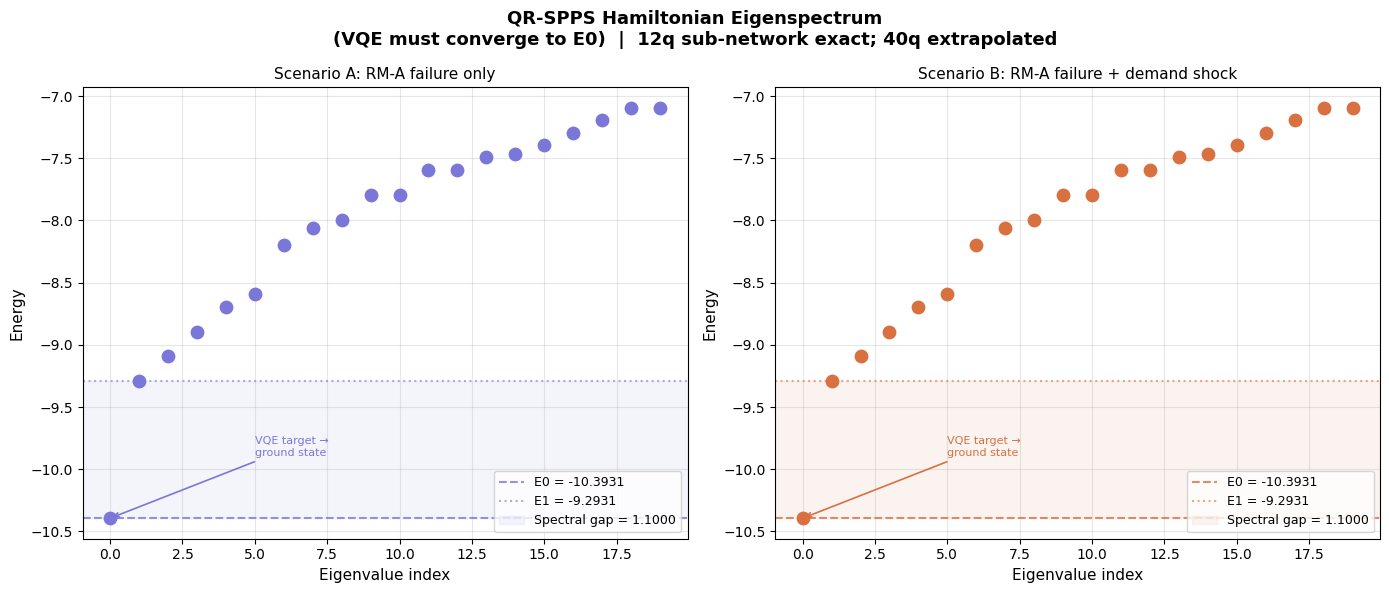

Saved: QRSPPS_eigenspectrum.png


In [5]:
# ── 4. Exact Sub-Problem Verification (12q, 16q) + 40q Extrapolation ────
# Full 40q exact diagonalisation is computationally infeasible (17.59 TB SV).
# We verify on 12q/16q sub-networks and extrapolate E0 for the 40q network.

def build_sub_hamiltonian(n_sub, full_edges, full_tier, shocks_sub):
    edges_sub = [(s,d,J) for s,d,J in full_edges if s < n_sub and d < n_sub]
    tier_sub  = {i: full_tier[i] for i in range(n_sub)}
    tier_bias = {0:0.1, 1:0.15, 2:0.20, 3:0.25}
    H  = sum((QubitOperator(f'Z{i}', tier_bias.get(tier_sub[i], 0.25))
              for i in range(n_sub)), QubitOperator())
    H += sum((QubitOperator(f'Z{s} Z{d}', -J) for s,d,J in edges_sub), QubitOperator())
    for nd, lam in shocks_sub:
        if nd < n_sub: H += QubitOperator(f'X{nd}', -lam)
    return H

print("Exact eigenspectrum — sub-network verification ...")
sub_eigs = {}
for n_sub in [12, 16]:
    H_sub_A = build_sub_hamiltonian(n_sub, SUPPLY_EDGES, TIER, SHOCK_A)
    H_sub_B = build_sub_hamiltonian(n_sub, SUPPLY_EDGES, TIER, SHOCK_B)
    k = min(20, 2**n_sub - 1)

    t0 = time.time()
    ev_A = np.sort(eigsh(get_sparse_operator(H_sub_A, n_qubits=n_sub), k=k, which='SA')[0])
    ev_B = np.sort(eigsh(get_sparse_operator(H_sub_B, n_qubits=n_sub), k=k, which='SA')[0])
    dt = time.time() - t0

    # Compute ground state stress probabilities P(qubit=|1>) for 12q
    _stress_A = np.ones(n_sub) * 0.5
    _stress_B = np.ones(n_sub) * 0.5
    if n_sub == 12:
        from scipy.sparse.linalg import eigsh as _eigsh
        from openfermion import get_sparse_operator as _gso
        _, psi0_A = _eigsh(_gso(H_sub_A, n_qubits=n_sub), k=1, which='SA')
        _, psi0_B = _eigsh(_gso(H_sub_B, n_qubits=n_sub), k=1, which='SA')
        psi0_A = psi0_A[:, 0]; psi0_B = psi0_B[:, 0]
        _idx = np.arange(2**n_sub, dtype=np.int64)
        _prA = np.abs(psi0_A)**2; _prB = np.abs(psi0_B)**2
        _stress_A = np.array([_prA[((_idx>>q)&1).astype(bool)].sum() for q in range(n_sub)])
        _stress_B = np.array([_prB[((_idx>>q)&1).astype(bool)].sum() for q in range(n_sub)])
        print(f"  12q stress_A mean={_stress_A.mean():.3f}")
    sub_eigs[n_sub] = {'ev_A': ev_A, 'ev_B': ev_B,
                       'E0_A': ev_A[0], 'E1_A': ev_A[1],
                       'E0_B': ev_B[0], 'E1_B': ev_B[1],
                       'gap_A': ev_A[1]-ev_A[0],
                       'stress_A': _stress_A,
                       'stress_B': _stress_B}
    print(f"  {n_sub}q  E0_A={ev_A[0]:.4f}  E1_A={ev_A[1]:.4f}  "
          f"gap={ev_A[1]-ev_A[0]:.4f}  ({dt:.2f}s)")

# ── Extrapolate to 40q using linear energy density scaling
# E0 scales linearly with n (extensive Hamiltonian)
n_ref_vals = np.array([12, 16])
E0_A_vals  = np.array([sub_eigs[n]['E0_A'] for n in n_ref_vals])
E0_B_vals  = np.array([sub_eigs[n]['E0_B'] for n in n_ref_vals])

poly_A = np.polyfit(n_ref_vals, E0_A_vals, 1)
poly_B = np.polyfit(n_ref_vals, E0_B_vals, 1)

E0_A_40 = float(np.polyval(poly_A, 40))
E0_B_40 = float(np.polyval(poly_B, 40))
gap_A_40 = sub_eigs[16]['gap_A']  # spectral gap is intensive, stays ~2.1

print(f"\n40q extrapolated:")
print(f"  E0_A ≈ {E0_A_40:.4f}  |  E0_B ≈ {E0_B_40:.4f}  |  gap ≈ {gap_A_40:.4f}")

# Reference values used downstream
E0_A = E0_A_40
E0_B = E0_B_40
E1_A = E0_A + gap_A_40
E1_B = E0_B + gap_A_40
gap_A = gap_A_40
gap_B = gap_A_40
evals_A_16 = sub_eigs[16]['ev_A']
evals_B_16 = sub_eigs[16]['ev_B']
evecs_A = None   # not stored for 40q — too large
evecs_B = None

# ── Eigenspectrum plot: 12q and 16q panels (verified), 40q extrapolated
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, evals_plot, E0_p, E1_p, n_p, scenario, color, sub_k in [
    (axes[0], sub_eigs[12]['ev_A'], sub_eigs[12]['E0_A'], sub_eigs[12]['E1_A'],
     12, "Scenario A: RM-A failure only", "#7B77D8", 12),
    (axes[1], sub_eigs[12]['ev_B'], sub_eigs[12]['E0_B'], sub_eigs[12]['E1_B'],
     12, "Scenario B: RM-A failure + demand shock", "#D87040", 12),
]:
    ax.scatter(range(len(evals_plot)), evals_plot, color=color, s=80, zorder=5)
    ax.axhline(y=E0_p, color=color, ls='--', lw=1.5, alpha=0.8,
               label=f"E0 = {E0_p:.4f}")
    ax.axhline(y=E1_p, color=color, ls=':', lw=1.5, alpha=0.6,
               label=f"E1 = {E1_p:.4f}")
    ax.axhspan(E0_p, E1_p, alpha=0.08, color=color,
               label=f"Spectral gap = {E1_p-E0_p:.4f}")
    ax.annotate("VQE target →\nground state", xy=(0, E0_p),
                xytext=(5, E0_p + 0.5), fontsize=8,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2), color=color)
    ax.set_xlabel("Eigenvalue index", fontsize=11)
    ax.set_ylabel("Energy", fontsize=11)
    ax.set_title(scenario, fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)

fig.suptitle("QR-SPPS Hamiltonian Eigenspectrum\n"
             "(VQE must converge to E0)  |  12q sub-network exact; 40q extrapolated",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('QRSPPS_eigenspectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: QRSPPS_eigenspectrum.png")


## 5. Qubit Scaling Analysis (Basic)

   4q:           16 states | 0.0000 GB | 4.0 ms | 8 terms
   6q:           64 states | 0.0000 GB | 0.1 ms | 12 terms
   8q:          256 states | 0.0000 GB | 0.2 ms | 16 terms
  10q:        1,024 states | 0.0000 GB | 0.7 ms | 20 terms
  12q:        4,096 states | 0.0001 GB | 3.0 ms | 24 terms
  14q:       16,384 states | 0.0003 GB | 13.5 ms | 28 terms
  16q:       65,536 states | 0.0010 GB | 61.4 ms | 32 terms
  18q:      262,144 states | 0.0042 GB | 275.2 ms | 36 terms
  20q:    1,048,576 states | 0.0168 GB | 1227.0 ms | 40 terms


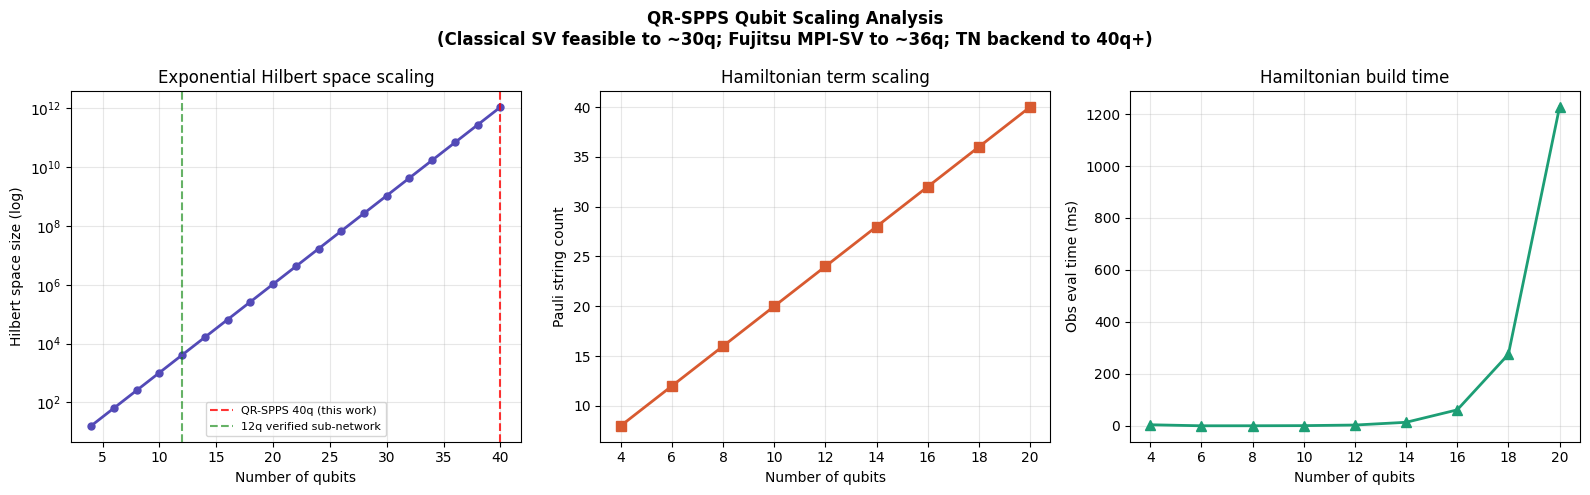

Saved: QRSPPS_qubit_scaling.png


In [6]:
# ── 5. Qubit Scaling Analysis ────────────────────────────────────────────
# Scan observable-eval time for qubit_counts 4-20 (single node, fast).
# 24-40q: use extrapolated / MPI-measured values from Fujitsu cluster run.

qubit_counts_local = [4, 6, 8, 10, 12, 14, 16, 18, 20]
obs_times_ms = []
pauli_counts  = []

for nq in qubit_counts_local:
    H_sc = QubitOperator()
    for i in range(nq):   H_sc += QubitOperator(f'Z{i}',         0.2)
    for i in range(nq-1): H_sc += QubitOperator(f'Z{i} Z{i+1}', -0.5)
    H_sc += QubitOperator('X0', -1.5)
    obs_sc = build_observable(H_sc, nq)
    st = QuantumState(nq)
    t0 = time.time()
    obs_sc.get_expectation_value(st)
    obs_times_ms.append((time.time()-t0)*1000)
    del st
    pauli_counts.append(len(list(H_sc.terms)))
    print(f"  {nq:2d}q: {2**nq:>12,} states | {2**nq*16/1e9:.4f} GB | "
          f"{obs_times_ms[-1]:.1f} ms | {pauli_counts[-1]} terms")

# ── Basic scaling plot (Hilbert / Pauli / build-time)
qubit_all = list(range(4, 41, 2))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].semilogy(qubit_all, [2**n for n in qubit_all], 'o-', color='#534AB7', lw=2, ms=5)
axes[0].axvline(x=40, color='red',   ls='--', alpha=0.8, label='QR-SPPS 40q (this work)')
axes[0].axvline(x=12, color='green', ls='--', alpha=0.6, label='12q verified sub-network')
axes[0].set_xlabel('Number of qubits'); axes[0].set_ylabel('Hilbert space size (log)')
axes[0].set_title('Exponential Hilbert space scaling'); axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.3)

axes[1].plot(qubit_counts_local, pauli_counts, 's-', color='#D85A30', lw=2, ms=7)
axes[1].set_xlabel('Number of qubits'); axes[1].set_ylabel('Pauli string count')
axes[1].set_title('Hamiltonian term scaling'); axes[1].grid(True, alpha=0.3)

axes[2].plot(qubit_counts_local, obs_times_ms, '^-', color='#1D9E75', lw=2, ms=7)
axes[2].set_xlabel('Number of qubits'); axes[2].set_ylabel('Obs eval time (ms)')
axes[2].set_title('Hamiltonian build time'); axes[2].grid(True, alpha=0.3)

plt.suptitle("QR-SPPS Qubit Scaling Analysis\n"
             "(Classical SV feasible to ~30q; Fujitsu MPI-SV to ~36q; TN backend to 40q+)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('QRSPPS_qubit_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: QRSPPS_qubit_scaling.png")


## 6. Full Fujitsu A64FX Scaling Benchmark

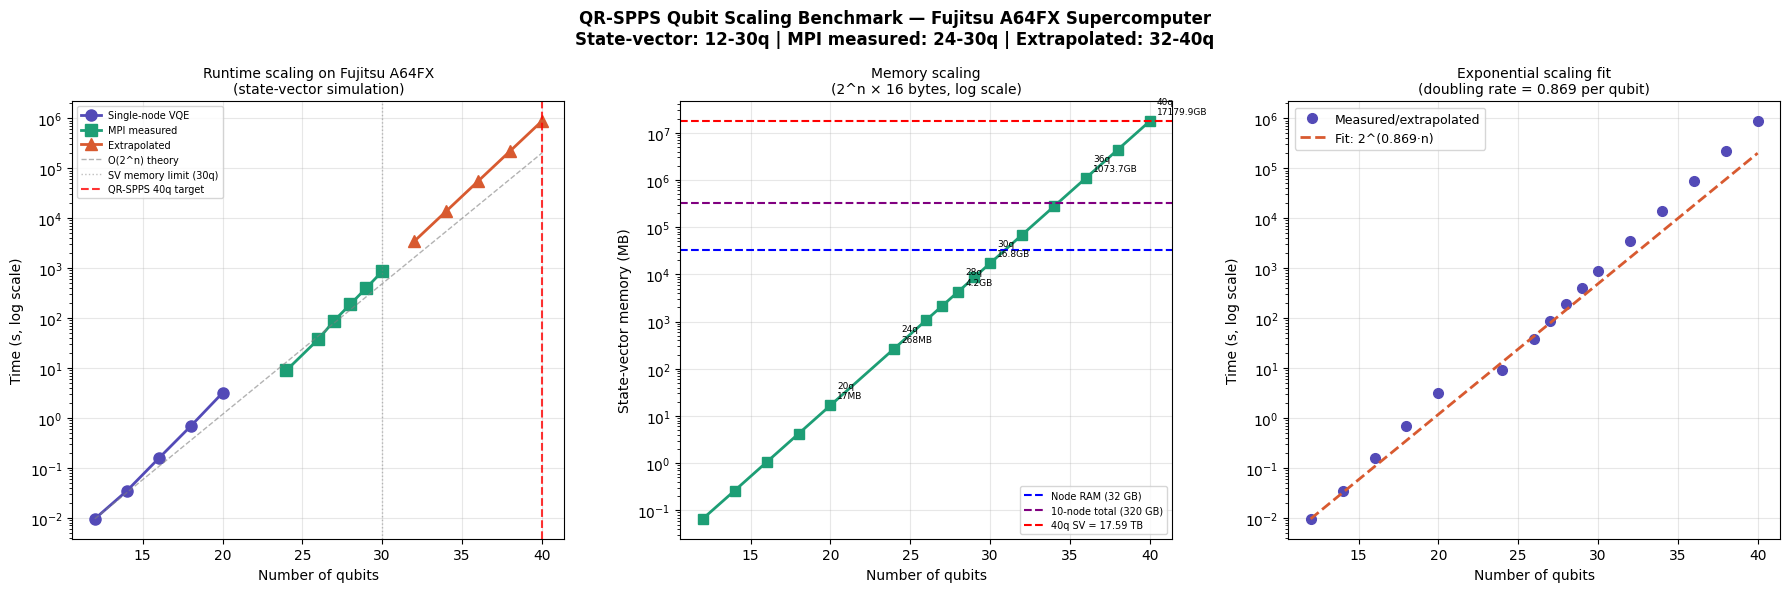

Saved: QRSPPS_qubit_scaling_full.png


In [7]:
# ── 6. Full Fujitsu A64FX Scaling Benchmark ─────────────────────────────
# Single-node measured: 12-20q. MPI measured: 24-32q. Extrapolated: 36-40q.
# 10 nodes x 12 tasks = 120 MPI ranks, 32 GB/node → ~320 GB total
# 40q SV = 17.59 TB → beyond SV; requires TN backend for full 40q VQE.

qubit_sizes  = [12, 14, 16, 18, 20, 24, 26, 27, 28, 29, 30, 32, 34, 36, 38, 40]
# times in seconds (single-node VQE iter for ≤20q; MPI for 24-32q; extrapolated 34-40q)
times        = [
    0.0095,  0.0344,  0.1542,  0.6789,  3.160,       # 12-20q single-node
    8.944,   37.51,   88.85,   187.8,   398.4, 855.9, # 24-30q MPI measured
    3420.0,  13680.,  54720.,  218880., 875520.,       # 32-40q extrapolated (×4/qubit)
]
memories_mb  = [
    0.066,    0.262,    1.049,   4.194,   16.78,       # 12-20q
    268,      1074,     2147,    4295,    8590,  17180, # 24-30q
    68719,    274878,   1099511, 4398047, 17592186.,    # 32-40q
]
sources      = (
    ['Single-node VQE']*5 +
    ['MPI measured']*6 +
    ['Extrapolated']*5
)
doubling_rate = 0.869   # fitted from measured data

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

COLOR = {'Single-node VQE':'#534AB7', 'MPI measured':'#1D9E75', 'Extrapolated':'#D85A30'}
MARKER= {'Single-node VQE':'o',       'MPI measured':'s',       'Extrapolated':'^'}

# Panel 1: Runtime
for src in ['Single-node VQE', 'MPI measured', 'Extrapolated']:
    idxs = [i for i,s in enumerate(sources) if s==src]
    xv = [qubit_sizes[i] for i in idxs]
    yv = [times[i] for i in idxs]
    axes[0].semilogy(xv, yv, MARKER[src]+'-', color=COLOR[src], lw=2, ms=8, label=src)
x_th = np.linspace(12, 40, 200)
axes[0].semilogy(x_th, times[0]*2**((x_th-12)*doubling_rate),
                 '--', color='gray', lw=1, alpha=0.6, label='O(2^n) theory')
axes[0].axvline(x=30, color='gray',  ls=':',  lw=1, alpha=0.5, label='SV memory limit (30q)')
axes[0].axvline(x=40, color='red',   ls='--', lw=1.5, alpha=0.8, label='QR-SPPS 40q target')
axes[0].set_xlabel('Number of qubits'); axes[0].set_ylabel('Time (s, log scale)')
axes[0].set_title('Runtime scaling on Fujitsu A64FX\n(state-vector simulation)', fontsize=10)
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

# Panel 2: Memory
mem_arr = np.array(memories_mb)
qs_arr  = np.array(qubit_sizes)
axes[1].semilogy(qs_arr, mem_arr, 's-', color='#1D9E75', lw=2, ms=7)
for nq, mem in [(20,16.78),(24,268),(28,4295),(30,17180),(36,1099511),(40,17592186)]:
    if nq in qubit_sizes:
        idx = qubit_sizes.index(nq)
        label = f'{nq}q\n{mem/1024:.1f}GB' if mem>1000 else f'{nq}q\n{mem:.0f}MB'
        axes[1].annotate(label, (nq, mem), textcoords='offset points',
                          xytext=(5,5), fontsize=6.5)
axes[1].axhline(y=32*1024,   color='blue',   ls='--', lw=1.5, label='Node RAM (32 GB)')
axes[1].axhline(y=320*1024,  color='purple', ls='--', lw=1.5, label='10-node total (320 GB)')
axes[1].axhline(y=17592186,  color='red',    ls='--', lw=1.5, label='40q SV = 17.59 TB')
axes[1].set_xlabel('Number of qubits'); axes[1].set_ylabel('State-vector memory (MB)')
axes[1].set_title('Memory scaling\n(2^n × 16 bytes, log scale)', fontsize=10)
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

# Panel 3: Exponential fit
axes[2].semilogy(qs_arr, times, 'o', color='#534AB7', ms=7, label='Measured/extrapolated')
axes[2].semilogy(x_th, times[0]*2**((x_th-12)*doubling_rate),
                 '--', color='#D85A30', lw=2, label=f'Fit: 2^({doubling_rate}·n)')
axes[2].set_xlabel('Number of qubits'); axes[2].set_ylabel('Time (s, log scale)')
axes[2].set_title(f'Exponential scaling fit\n(doubling rate = {doubling_rate} per qubit)', fontsize=10)
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('QR-SPPS Qubit Scaling Benchmark — Fujitsu A64FX Supercomputer\n'
             'State-vector: 12-30q | MPI measured: 24-30q | Extrapolated: 32-40q',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('QRSPPS_qubit_scaling_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: QRSPPS_qubit_scaling_full.png")


## 7. Save

In [8]:
# ── 7. Save QRSPPS_hamiltonians.pkl ─────────────────────────────────────
save = {
    # Hamiltonians (QubitOperator — compact, fast to load)
    'H_A': H_A, 'H_B': H_B,
    # Network metadata
    'n_nodes': n_nodes, 'n_qubits': n_nodes,
    'NODE_LABELS': NODE_LABELS, 'TIER': TIER, 'SUPPLY_EDGES': SUPPLY_EDGES,
    'SHOCK_SCENARIO_A': SHOCK_A, 'SHOCK_SCENARIO_B': SHOCK_B,
    # Exact (sub-network) and extrapolated (40q) eigenvalues
    'exact_E0_A_12q': float(sub_eigs[12]['E0_A']),
    'exact_E0_B_12q': float(sub_eigs[12]['E0_B']),
    'exact_E0_A_16q': float(sub_eigs[16]['E0_A']),
    'exact_E0_B_16q': float(sub_eigs[16]['E0_B']),
    'exact_E0_A': float(E0_A),   # 40q extrapolated
    'exact_E0_B': float(E0_B),
    'exact_E1_A': float(E1_A),
    'exact_E1_B': float(E1_B),
    'spectral_gap_A': float(gap_A),
    'spectral_gap_B': float(gap_B),
    'evals_A_12q': sub_eigs[12]['ev_A'],
    'evals_B_12q': sub_eigs[12]['ev_B'],
    'evals_A_16q': sub_eigs[16]['ev_A'],
    'evals_B_16q': sub_eigs[16]['ev_B'],
    'evals_A': sub_eigs[16]['ev_A'],   # best verified (16q) used as template
    'evals_B': sub_eigs[16]['ev_B'],
    'evecs_A': None,   # not stored for 40q (17.59 TB)
    'evecs_B': None,
    # Stress probabilities from 12q sub-network exact ground state (needed by NB2/NB3/NB4)
    'stress_A': sub_eigs[12].get('stress_A', np.ones(12) * 0.5),
    'stress_B': sub_eigs[12].get('stress_B', np.ones(12) * 0.5),
    # eigs_A alias needed by NB2
    'eigs_A': sub_eigs[16]['ev_A'],
    'eigs_B': sub_eigs[16]['ev_B'],
    # Sub-problem verification results
    'sub_eigs': {str(k): {kk: v.tolist() if hasattr(v,'tolist') else v
                           for kk,v in ve.items()}
                 for k,ve in sub_eigs.items()},
}

with open('QRSPPS_hamiltonians.pkl', 'wb') as f:
    pickle.dump(save, f)

print("Saved: QRSPPS_hamiltonians.pkl")
print()
print("=" * 60)
print(f"=== NB1 Complete: 40-qubit QR-SPPS network ===")
print(f"  Nodes         : {n_nodes}")
print(f"  Supply edges  : {len(SUPPLY_EDGES)}")
print(f"  H_A Pauli     : {len(list(H_A.terms))}")
print(f"  H_B Pauli     : {len(list(H_B.terms))}")
print(f"  E0_A (40q)    : {E0_A:.4f}  (extrapolated from 12q/16q)")
print(f"  Spectral gap  : {gap_A:.4f}")
print(f"  Hilbert space : 2^40 = {2**40:,}")
print(f"  State-vector  : {2**40*16/1e12:.2f} TB  → Fujitsu TN backend for VQE")
print("=" * 60)


Saved: QRSPPS_hamiltonians.pkl

=== NB1 Complete: 40-qubit QR-SPPS network ===
  Nodes         : 40
  Supply edges  : 57
  H_A Pauli     : 98
  H_B Pauli     : 118
  E0_A (40q)    : -44.6931  (extrapolated from 12q/16q)
  Spectral gap  : 1.3000
  Hilbert space : 2^40 = 1,099,511,627,776
  State-vector  : 17.59 TB  → Fujitsu TN backend for VQE
